# YouTube Channel Data Analysis

## Project Overview
This notebook analyzes YouTube channel data to answer three key questions:
1. **Which channels/categories grow fastest?**
2. **Does upload frequency affect views?**
3. **Which category gets the most engagement?**

**Dataset**: YouTube video statistics and comments data

**Date**: March 2026

## 1. Import Required Libraries

In [12]:
# Import necessary libraries
import sys
import os
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Import custom modules
from cleaning import load_data, clean_videos_data, clean_comments_data, merge_data
from analysis import (analyze_channel_growth, analyze_upload_frequency_vs_views, 
                     analyze_category_engagement, get_top_performing_videos,
                     analyze_sentiment_by_category, create_summary_statistics)

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## 2. Load and Explore the Dataset

In [13]:
# Load the raw data
print("Loading data...")
videos_df, comments_df = load_data()

print(f"\n📊 Dataset Overview:")
print(f"  - Total videos: {len(videos_df)}")
print(f"  - Total comments: {len(comments_df)}")

print("\n📹 Videos Data - First 5 rows:")
display(videos_df.head())

print("\n💬 Comments Data - First 5 rows:")
display(comments_df.head())

print("\n📋 Videos Data Info:")
print(videos_df.info())

print("\n📋 Videos Data Summary Statistics:")
display(videos_df.describe())

Loading data...

📊 Dataset Overview:
  - Total videos: 1881
  - Total comments: 18409

📹 Videos Data - First 5 rows:


,Unnamed: 0,Title,Video ID,Published At,Keyword,Likes,Comments,Views
0,0,Apple Pay Is Killing the Physical Wallet After...,wAZZ-UWGVHI,2022-08-23,tech,3407.0,672.0,135612.0
1,1,The most EXPENSIVE thing I own.,b3x28s61q3c,2022-08-24,tech,76779.0,4306.0,1758063.0
2,2,My New House Gaming Setup is SICK!,4mgePWWCAmA,2022-08-23,tech,63825.0,3338.0,1564007.0
3,3,Petrol Vs Liquid Nitrogen | Freezing Experimen...,kXiYSI7H2b0,2022-08-23,tech,71566.0,1426.0,922918.0
4,4,Best Back to School Tech 2022!,ErMwWXQxHp0,2022-08-08,tech,96513.0,5155.0,1855644.0



💬 Comments Data - First 5 rows:


,Unnamed: 0,Video ID,Comment,Likes,Sentiment
0,0,wAZZ-UWGVHI,Let's not forget that Apple Pay in 2014 requir...,95.0,1.0
1,1,wAZZ-UWGVHI,Here in NZ 50% of retailers don’t even have co...,19.0,0.0
2,2,wAZZ-UWGVHI,I will forever acknowledge this channel with t...,161.0,2.0
3,3,wAZZ-UWGVHI,Whenever I go to a place that doesn’t take App...,8.0,0.0
4,4,wAZZ-UWGVHI,"Apple Pay is so convenient, secure, and easy t...",34.0,2.0



📋 Videos Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1881 entries, 0 to 1880
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    1881 non-null   int64  
 1   Title         1881 non-null   object 
 2   Video ID      1881 non-null   object 
 3   Published At  1881 non-null   object 
 4   Keyword       1881 non-null   object 
 5   Likes         1879 non-null   float64
 6   Comments      1879 non-null   float64
 7   Views         1879 non-null   float64
dtypes: float64(3), int64(1), object(4)
memory usage: 117.7+ KB
None

📋 Videos Data Summary Statistics:


,Unnamed: 0,Likes,Comments,Views
count,1881.000000,1.879000e+03,1879.000000,1.879000e+03
mean,940.000000,1.700610e+05,7863.331559,1.161292e+07
std,543.142247,7.962293e+05,37879.964926,1.084450e+08
min,0.000000,-1.000000e+00,-1.000000,2.500000e+01
25%,470.000000,2.672500e+03,199.000000,8.451500e+04
50%,940.000000,1.478700e+04,814.000000,5.917210e+05
75%,1410.000000,6.090600e+04,3377.500000,2.804978e+06
max,1880.000000,1.644556e+07,732818.000000,4.034122e+09


## 3. Data Cleaning and Preprocessing

In [14]:
# Clean the data
print("Cleaning videos data...")
videos_clean = clean_videos_data(videos_df)

print("Cleaning comments data...")
comments_clean = clean_comments_data(comments_df)

print("\n✓ Data cleaning complete!")
print(f"\n📊 Cleaned Data Overview:")
print(f"  - Videos: {len(videos_clean)} rows")
print(f"  - Comments: {len(comments_clean)} rows")
print(f"  - Date range: {videos_clean['Published At'].min()} to {videos_clean['Published At'].max()}")
print(f"  - Categories: {videos_clean['Keyword'].nunique()}")

print("\n📹 New Columns Added to Videos Data:")
new_cols = [col for col in videos_clean.columns if col not in videos_df.columns]
for col in new_cols:
    print(f"  - {col}")

display(videos_clean.head())

Cleaning videos data...
Cleaning comments data...

✓ Data cleaning complete!

📊 Cleaned Data Overview:
  - Videos: 1881 rows
  - Comments: 18160 rows
  - Date range: 2007-07-16 00:00:00 to 2022-08-24 00:00:00
  - Categories: 41

📹 New Columns Added to Videos Data:
  - Year
  - Month
  - Day
  - Day_of_Week
  - Engagement_Rate
  - Like_Rate
  - Comment_Rate


,Title,Video ID,Published At,Keyword,Likes,Comments,Views,Year,Month,Day,Day_of_Week,Engagement_Rate,Like_Rate,Comment_Rate
0,Apple Pay Is Killing the Physical Wallet After...,wAZZ-UWGVHI,2022-08-23,tech,3407.0,672.0,135612.0,2022,8,23,Tuesday,3.007824,2.512296,0.495528
1,The most EXPENSIVE thing I own.,b3x28s61q3c,2022-08-24,tech,76779.0,4306.0,1758063.0,2022,8,24,Wednesday,4.612176,4.367247,0.244929
2,My New House Gaming Setup is SICK!,4mgePWWCAmA,2022-08-23,tech,63825.0,3338.0,1564007.0,2022,8,23,Tuesday,4.294287,4.080861,0.213426
3,Petrol Vs Liquid Nitrogen | Freezing Experimen...,kXiYSI7H2b0,2022-08-23,tech,71566.0,1426.0,922918.0,2022,8,23,Tuesday,7.908820,7.754310,0.154510
4,Best Back to School Tech 2022!,ErMwWXQxHp0,2022-08-08,tech,96513.0,5155.0,1855644.0,2022,8,8,Monday,5.478850,5.201049,0.277801


## 4. Question 1: Which Channels/Categories Grow Fastest?

We'll analyze channel growth by examining:
- Total views and engagement metrics
- Growth scores based on multiple factors
- Average performance per video

In [15]:
# Analyze channel growth
growth_analysis = analyze_channel_growth(videos_clean)

print("🚀 CHANNEL GROWTH ANALYSIS")
print("="*70)
display(growth_analysis)

print("\n📊 Top 5 Fastest Growing Categories:")
top_5_growth = growth_analysis.head(5)
display(top_5_growth[['Keyword', 'Total_Views', 'Avg_Views_Per_Video', 
                       'Avg_Engagement_Rate', 'Growth_Score']])

🚀 CHANNEL GROWTH ANALYSIS


,Keyword,Total_Views,Avg_Views_Per_Video,Std_Views,Total_Likes,Avg_Likes,Total_Comments,Avg_Comments,Video_Count,Avg_Engagement_Rate,Growth_Score
0,google,4.651424e+09,1.033650e+08,6.005725e+08,21202537.0,471167.49,1019079.0,22646.20,45,2.62,1.867134e+09
1,animals,3.599511e+09,9.472396e+07,2.890292e+08,28909480.0,760775.79,831129.0,21871.82,38,1.05,1.448643e+09
2,mrbeast,3.338200e+09,6.676400e+07,6.183950e+07,105295718.0,2105914.36,4797224.0,95944.48,50,3.60,1.367829e+09
3,bed,2.371302e+09,5.389323e+07,1.079863e+08,20842016.0,473682.18,667962.0,15180.95,44,1.58,9.549072e+08
4,music,1.350785e+09,2.936489e+07,1.387371e+08,14452653.0,314188.11,565291.0,12288.93,46,3.39,5.447632e+08
5,cubes,7.519370e+08,1.503874e+07,2.895526e+07,15153060.0,303061.20,341654.0,6833.08,50,2.96,3.053893e+08
6,history,7.523565e+08,1.504713e+07,6.458395e+07,13670533.0,273410.66,1009501.0,20190.02,50,2.90,3.052460e+08
7,mukbang,4.907148e+08,1.090477e+07,2.363488e+07,6363299.0,141406.64,335312.0,7451.38,45,3.21,1.982623e+08
8,apple,4.513711e+08,1.074693e+07,6.557384e+07,4959314.0,118078.90,361992.0,8618.86,42,3.94,1.821090e+08
9,sports,4.214590e+08,8.601205e+06,1.760032e+07,4435425.0,90518.88,187573.0,3828.02,49,1.32,1.699519e+08



📊 Top 5 Fastest Growing Categories:


,Keyword,Total_Views,Avg_Views_Per_Video,Avg_Engagement_Rate,Growth_Score
0,google,4.651424e+09,1.033650e+08,2.62,1.867134e+09
1,animals,3.599511e+09,9.472396e+07,1.05,1.448643e+09
2,mrbeast,3.338200e+09,6.676400e+07,3.60,1.367829e+09
3,bed,2.371302e+09,5.389323e+07,1.58,9.549072e+08
4,music,1.350785e+09,2.936489e+07,3.39,5.447632e+08


## 5. Question 2: Does Upload Frequency Affect Views?

We'll analyze the correlation between:
- Number of videos uploaded per time period
- Average views received
- Correlation coefficients by category

In [16]:
# Analyze upload frequency vs views
freq_correlation, freq_data = analyze_upload_frequency_vs_views(videos_clean)

print("📈 UPLOAD FREQUENCY vs VIEWS ANALYSIS")
print("="*70)
print("\nCorrelation between Upload Frequency and Views by Category:")
display(freq_correlation)

print("\n🔍 Key Insights:")
for idx, row in freq_correlation.iterrows():
    corr = row['Correlation_Freq_Views']
    if pd.notna(corr):
        category = row['Category']
        avg_freq = row['Avg_Upload_Frequency']
        avg_views = row['Avg_Views']
        
        if corr > 0.3:
            relationship = "POSITIVE correlation"
        elif corr < -0.3:
            relationship = "NEGATIVE correlation"
        else:
            relationship = "WEAK/NO correlation"
            
        print(f"  - {category.upper()}: {relationship} (r={corr:.2f})")
        print(f"    Avg upload frequency: {avg_freq:.2f} videos/period, Avg views: {avg_views:,.0f}")

📈 UPLOAD FREQUENCY vs VIEWS ANALYSIS

Correlation between Upload Frequency and Views by Category:


,Category,Avg_Upload_Frequency,Avg_Views,Correlation_Freq_Views
0,animals,1.31,1.171852e+08,-0.13
1,apple,7.00,7.297840e+07,-0.25
2,asmr,7.14,8.891756e+06,-0.34
3,bed,1.33,6.399156e+07,-0.19
4,biology,1.24,4.394152e+06,-0.12
5,business,2.40,7.573307e+06,-0.01
6,chess,3.13,3.518580e+06,-0.27
7,cnn,25.00,4.951808e+05,1.00
8,computer science,1.45,1.372086e+06,-0.18
9,crypto,25.00,4.564463e+06,-1.00



🔍 Key Insights:
  - ANIMALS: WEAK/NO correlation (r=-0.13)
    Avg upload frequency: 1.31 videos/period, Avg views: 117,185,193
  - APPLE: WEAK/NO correlation (r=-0.25)
    Avg upload frequency: 7.00 videos/period, Avg views: 72,978,404
  - ASMR: NEGATIVE correlation (r=-0.34)
    Avg upload frequency: 7.14 videos/period, Avg views: 8,891,756
  - BED: WEAK/NO correlation (r=-0.19)
    Avg upload frequency: 1.33 videos/period, Avg views: 63,991,560
  - BIOLOGY: WEAK/NO correlation (r=-0.12)
    Avg upload frequency: 1.24 videos/period, Avg views: 4,394,152
  - BUSINESS: WEAK/NO correlation (r=-0.01)
    Avg upload frequency: 2.40 videos/period, Avg views: 7,573,307
  - CHESS: WEAK/NO correlation (r=-0.27)
    Avg upload frequency: 3.13 videos/period, Avg views: 3,518,580
  - CNN: POSITIVE correlation (r=1.00)
    Avg upload frequency: 25.00 videos/period, Avg views: 495,181
  - COMPUTER SCIENCE: WEAK/NO correlation (r=-0.18)
    Avg upload frequency: 1.45 videos/period, Avg views: 1,37

## 6. Question 3: Which Category Gets the Most Engagement?

We'll examine engagement metrics including:
- Engagement rate (likes + comments per view)
- Like rate
- Comment rate
- Overall engagement score

In [17]:
# Analyze category engagement
engagement_analysis = analyze_category_engagement(videos_clean)

print("💬 CATEGORY ENGAGEMENT ANALYSIS")
print("="*70)
display(engagement_analysis)

print("\n🏆 Top 5 Most Engaging Categories:")
top_5_engagement = engagement_analysis.head(5)
display(top_5_engagement[['Keyword', 'Avg_Views', 'Avg_Likes', 'Avg_Comments',
                          'Avg_Engagement_Rate', 'Engagement_Score']])

print("\n📊 Winner: Highest Overall Engagement")
winner = engagement_analysis.iloc[0]
print(f"  Category: {winner['Keyword'].upper()}")
print(f"  Engagement Score: {winner['Engagement_Score']:.2f}")
print(f"  Avg Engagement Rate: {winner['Avg_Engagement_Rate']:.2f}%")
print(f"  Avg Like Rate: {winner['Avg_Like_Rate']:.2f}%")
print(f"  Avg Comment Rate: {winner['Avg_Comment_Rate']:.2f}%")

💬 CATEGORY ENGAGEMENT ANALYSIS


,Keyword,Total_Views,Avg_Views,Total_Likes,Avg_Likes,Total_Comments,Avg_Comments,Avg_Engagement_Rate,Avg_Like_Rate,Avg_Comment_Rate,Video_Count,Engagement_Score
0,crypto,2.023041e+07,4.046082e+05,426068.0,8521.36,27331.0,546.62,8.80,7.07,1.72,50,6.157
1,reaction,3.115862e+07,6.231725e+05,3697989.0,73959.78,162336.0,3246.72,7.56,6.87,0.70,50,5.295
2,gaming,2.234476e+07,5.196455e+05,1070583.0,24897.28,59207.0,1376.91,6.96,6.52,0.45,43,4.875
3,asmr,8.533079e+07,1.706616e+06,1830765.0,36615.30,61365.0,1227.30,5.55,5.14,0.41,50,3.885
4,trolling,7.100705e+07,1.420141e+06,3069352.0,61387.04,152841.0,3056.82,5.30,4.89,0.41,50,3.710
5,game development,3.623443e+07,7.246885e+05,1308934.0,26178.68,68817.0,1376.34,5.26,4.86,0.40,50,3.682
6,nintendo,7.992203e+07,1.665042e+06,2139530.0,44573.54,177347.0,3694.73,5.26,4.67,0.59,48,3.682
7,minecraft,9.063854e+07,1.812771e+06,3058978.0,61179.56,142186.0,2843.72,5.18,4.96,0.22,50,3.626
8,xbox,8.349506e+07,1.703981e+06,1902183.0,38820.06,140651.0,2870.43,4.97,4.16,0.81,49,3.479
9,marvel,3.307040e+08,6.614080e+06,10518960.0,210379.20,485034.0,9700.68,4.12,3.87,0.25,50,2.884



🏆 Top 5 Most Engaging Categories:


,Keyword,Avg_Views,Avg_Likes,Avg_Comments,Avg_Engagement_Rate,Engagement_Score
0,crypto,404608.22,8521.36,546.62,8.80,6.157
1,reaction,623172.46,73959.78,3246.72,7.56,5.295
2,gaming,519645.49,24897.28,1376.91,6.96,4.875
3,asmr,1706615.82,36615.30,1227.30,5.55,3.885
4,trolling,1420141.02,61387.04,3056.82,5.30,3.710



📊 Winner: Highest Overall Engagement
  Category: CRYPTO
  Engagement Score: 6.16
  Avg Engagement Rate: 8.80%
  Avg Like Rate: 7.07%
  Avg Comment Rate: 1.72%


## 7. Visualizations

Visual representations of our key findings

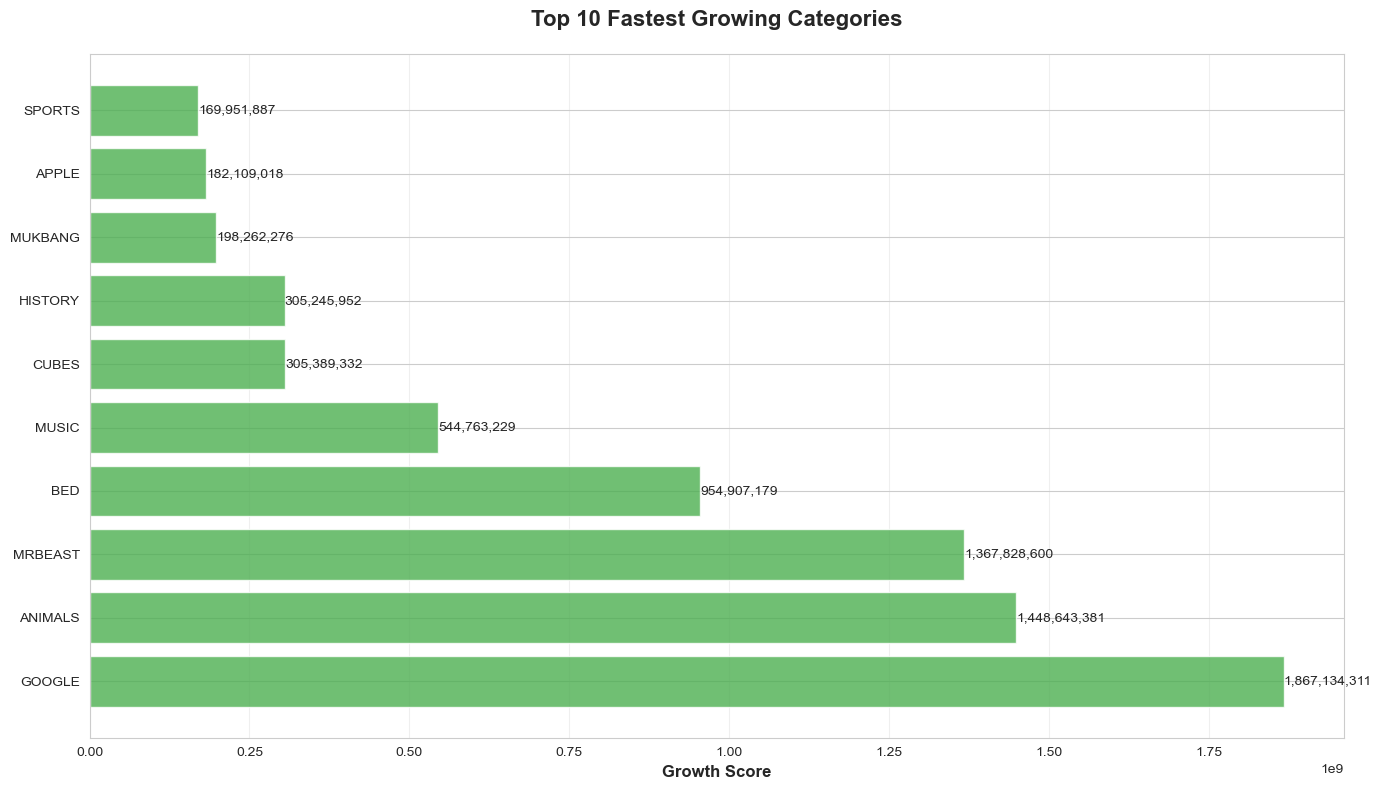

✓ Chart saved to visuals/channel_growth.png


In [7]:
# Visualization 1: Channel Growth Comparison
fig, ax = plt.subplots(figsize=(14, 8))

top_10_growth = growth_analysis.head(10)
x_pos = np.arange(len(top_10_growth))

ax.barh(x_pos, top_10_growth['Growth_Score'], color='#4CAF50', alpha=0.8)
ax.set_yticks(x_pos)
ax.set_yticklabels(top_10_growth['Keyword'].str.upper())
ax.set_xlabel('Growth Score', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Fastest Growing Categories', fontsize=16, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(top_10_growth['Growth_Score']):
    ax.text(v + 50000, i, f'{v:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../visuals/channel_growth.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Chart saved to visuals/channel_growth.png")

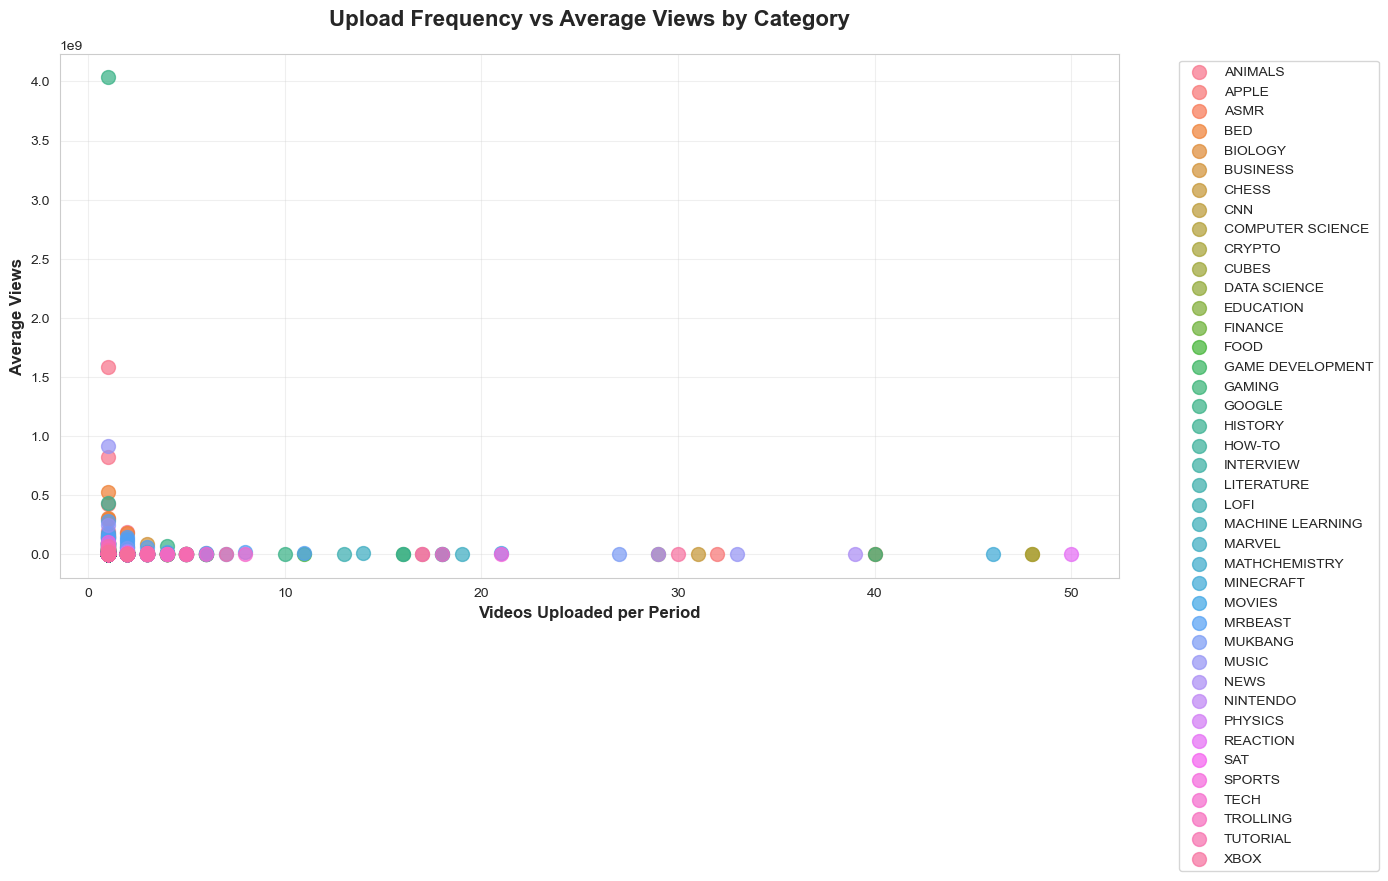

✓ Chart saved to visuals/upload_frequency_vs_views.png


In [8]:
# Visualization 2: Upload Frequency vs Views Scatter Plot
fig, ax = plt.subplots(figsize=(14, 8))

categories = freq_data['Category'].unique()
colors = sns.color_palette('husl', len(categories))

for i, category in enumerate(categories):
    cat_data = freq_data[freq_data['Category'] == category]
    ax.scatter(cat_data['Videos_Uploaded'], cat_data['Avg_Views'], 
              label=category.upper(), alpha=0.7, s=100, color=colors[i])

ax.set_xlabel('Videos Uploaded per Period', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Views', fontsize=12, fontweight='bold')
ax.set_title('Upload Frequency vs Average Views by Category', fontsize=16, fontweight='bold', pad=20)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../visuals/upload_frequency_vs_views.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Chart saved to visuals/upload_frequency_vs_views.png")

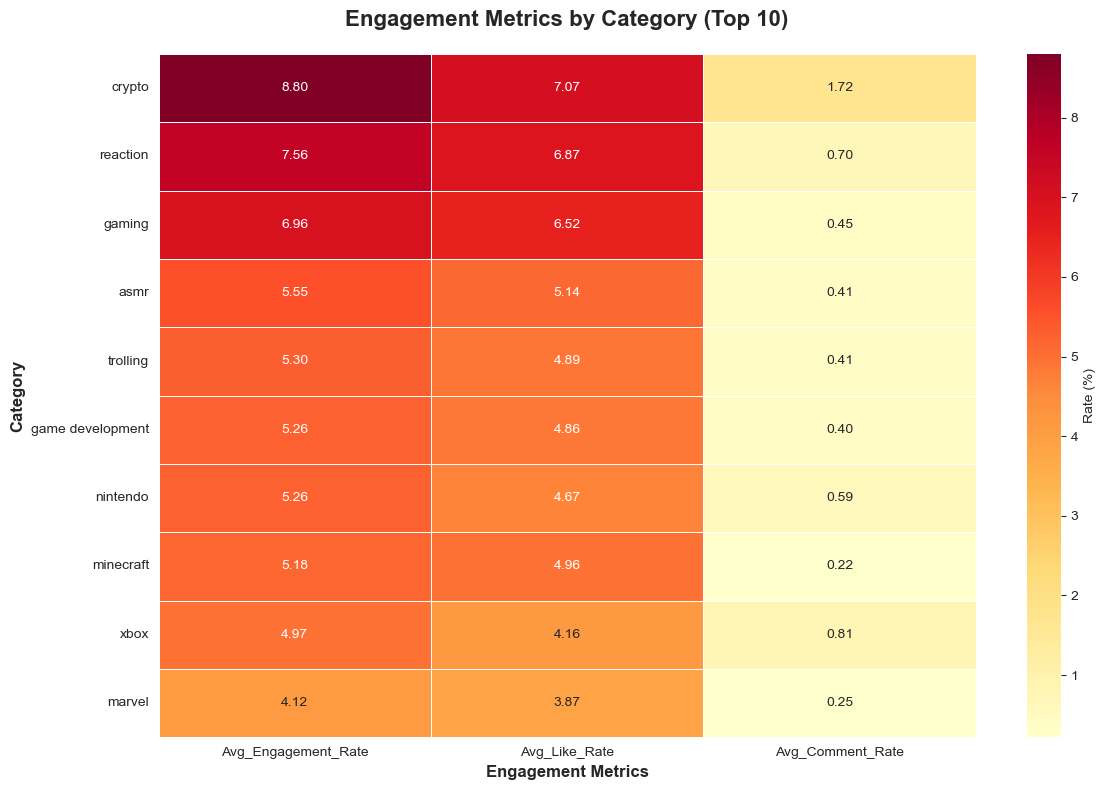

✓ Chart saved to visuals/category_engagement_heatmap.png


In [9]:
# Visualization 3: Category Engagement Heatmap
fig, ax = plt.subplots(figsize=(12, 8))

# Prepare data for heatmap
engagement_viz = engagement_analysis.set_index('Keyword')[
    ['Avg_Engagement_Rate', 'Avg_Like_Rate', 'Avg_Comment_Rate']
].head(10)

sns.heatmap(engagement_viz, annot=True, fmt='.2f', cmap='YlOrRd', 
            cbar_kws={'label': 'Rate (%)'}, ax=ax, linewidths=0.5)

ax.set_title('Engagement Metrics by Category (Top 10)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Engagement Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Category', fontsize=12, fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('../visuals/category_engagement_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Chart saved to visuals/category_engagement_heatmap.png")

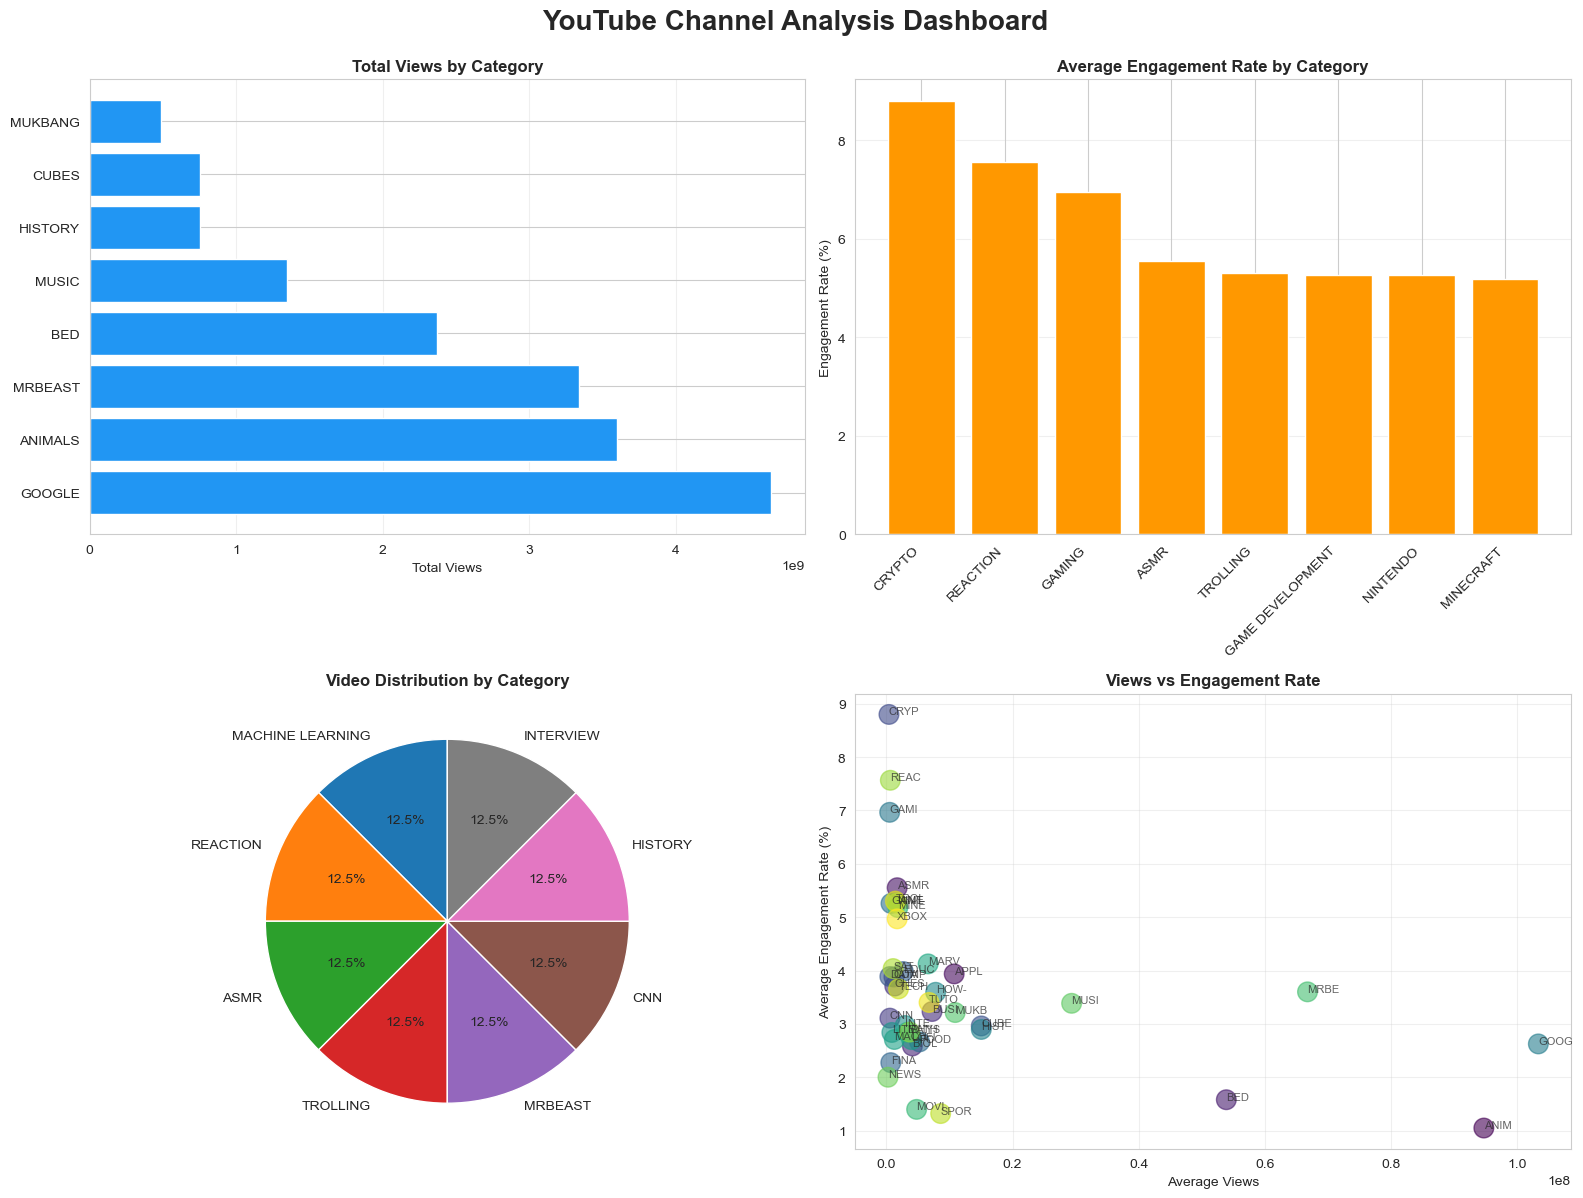

✓ Chart saved to visuals/comprehensive_dashboard.png


In [10]:
# Visualization 4: Comprehensive Dashboard - Top Categories
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('YouTube Channel Analysis Dashboard', fontsize=20, fontweight='bold', y=0.995)

# Subplot 1: Total Views by Category
top_views = videos_clean.groupby('Keyword')['Views'].sum().sort_values(ascending=False).head(8)
axes[0, 0].barh(range(len(top_views)), top_views.values, color='#2196F3')
axes[0, 0].set_yticks(range(len(top_views)))
axes[0, 0].set_yticklabels(top_views.index.str.upper())
axes[0, 0].set_xlabel('Total Views')
axes[0, 0].set_title('Total Views by Category', fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# Subplot 2: Average Engagement Rate
top_engagement = engagement_analysis.head(8)
axes[0, 1].bar(range(len(top_engagement)), top_engagement['Avg_Engagement_Rate'], color='#FF9800')
axes[0, 1].set_xticks(range(len(top_engagement)))
axes[0, 1].set_xticklabels(top_engagement['Keyword'].str.upper(), rotation=45, ha='right')
axes[0, 1].set_ylabel('Engagement Rate (%)')
axes[0, 1].set_title('Average Engagement Rate by Category', fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Subplot 3: Video Count by Category
video_count = videos_clean['Keyword'].value_counts().head(8)
axes[1, 0].pie(video_count.values, labels=video_count.index.str.upper(), autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Video Distribution by Category', fontweight='bold')

# Subplot 4: Views vs Engagement Scatter
category_stats = videos_clean.groupby('Keyword').agg({
    'Views': 'mean',
    'Engagement_Rate': 'mean'
}).reset_index()

scatter = axes[1, 1].scatter(category_stats['Views'], category_stats['Engagement_Rate'], 
                             s=200, alpha=0.6, c=range(len(category_stats)), cmap='viridis')
axes[1, 1].set_xlabel('Average Views')
axes[1, 1].set_ylabel('Average Engagement Rate (%)')
axes[1, 1].set_title('Views vs Engagement Rate', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

# Add category labels to scatter plot
for idx, row in category_stats.iterrows():
    axes[1, 1].annotate(row['Keyword'].upper()[:4], 
                       (row['Views'], row['Engagement_Rate']),
                       fontsize=8, alpha=0.7)

plt.tight_layout()
plt.savefig('../visuals/comprehensive_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Chart saved to visuals/comprehensive_dashboard.png")

## 8. Summary & Conclusions

### Key Findings

In [11]:
# Generate comprehensive summary
summary = create_summary_statistics(videos_clean)

print("="*70)
print("📊 YOUTUBE CHANNEL DATA ANALYSIS - EXECUTIVE SUMMARY")
print("="*70)

print("\n📈 DATASET OVERVIEW:")
print(f"  • Total Videos Analyzed: {summary['total_videos']:,}")
print(f"  • Total Views: {summary['total_views']:,.0f}")
print(f"  • Total Likes: {summary['total_likes']:,.0f}")
print(f"  • Total Comments: {summary['total_comments']:,.0f}")
print(f"  • Number of Categories: {summary['categories_count']}")
print(f"  • Date Range: {summary['date_range']}")

print("\n🚀 QUESTION 1: Which channels/categories grow fastest?")
top_growth = growth_analysis.iloc[0]
print(f"  ANSWER: {top_growth['Keyword'].upper()}")
print(f"  • Growth Score: {top_growth['Growth_Score']:,.0f}")
print(f"  • Total Views: {top_growth['Total_Views']:,.0f}")
print(f"  • Avg Views per Video: {top_growth['Avg_Views_Per_Video']:,.0f}")
print(f"  • Avg Engagement Rate: {top_growth['Avg_Engagement_Rate']:.2f}%")

print("\n📊 QUESTION 2: Does upload frequency affect views?")
print(f"  ANSWER: Correlation varies by category")
for idx, row in freq_correlation.head(3).iterrows():
    if pd.notna(row['Correlation_Freq_Views']):
        print(f"  • {row['Category'].upper()}: Correlation = {row['Correlation_Freq_Views']:.2f}")

print("\n💬 QUESTION 3: Which category gets the most engagement?")
top_eng = engagement_analysis.iloc[0]
print(f"  ANSWER: {top_eng['Keyword'].upper()}")
print(f"  • Engagement Score: {top_eng['Engagement_Score']:.2f}")
print(f"  • Avg Engagement Rate: {top_eng['Avg_Engagement_Rate']:.2f}%")
print(f"  • Avg Like Rate: {top_eng['Avg_Like_Rate']:.2f}%")
print(f"  • Avg Comment Rate: {top_eng['Avg_Comment_Rate']:.2f}%")

print("\n🏆 TOP 3 PERFORMING VIDEOS:")
top_videos = get_top_performing_videos(videos_clean, n=3)
for i, (idx, video) in enumerate(top_videos.iterrows(), 1):
    print(f"\n  {i}. {video['Title'][:60]}...")
    print(f"     Category: {video['Keyword'].upper()} | Views: {video['Views']:,.0f} | Likes: {video['Likes']:,.0f}")

print("\n" + "="*70)
print("✓ Analysis Complete!")

📊 YOUTUBE CHANNEL DATA ANALYSIS - EXECUTIVE SUMMARY

📈 DATASET OVERVIEW:
  • Total Videos Analyzed: 1,881
  • Total Views: 21,820,670,087
  • Total Likes: 319,544,658
  • Total Comments: 14,775,200
  • Number of Categories: 41
  • Date Range: 2007-07-16 00:00:00 to 2022-08-24 00:00:00

🚀 QUESTION 1: Which channels/categories grow fastest?
  ANSWER: GOOGLE
  • Growth Score: 1,867,134,311
  • Total Views: 4,651,423,680
  • Avg Views per Video: 103,364,971
  • Avg Engagement Rate: 2.62%

📊 QUESTION 2: Does upload frequency affect views?
  ANSWER: Correlation varies by category
  • ANIMALS: Correlation = -0.13
  • APPLE: Correlation = -0.25
  • ASMR: Correlation = -0.34

💬 QUESTION 3: Which category gets the most engagement?
  ANSWER: CRYPTO
  • Engagement Score: 6.16
  • Avg Engagement Rate: 8.80%
  • Avg Like Rate: 7.07%
  • Avg Comment Rate: 1.72%

🏆 TOP 3 PERFORMING VIDEOS:

  1. El Chombo - Dame Tu Cosita feat. Cutty Ranks (Official Video...
     Category: GOOGLE | Views: 4,034,122,27

## 9. Advanced Feature: Statistical Significance and Confidence Intervals

This section adds inferential analysis to avoid relying only on point estimates.

What is included:
- Bootstrap confidence intervals for engagement rate by category.
- Permutation-test p-values for upload frequency vs views correlations.

In [22]:
import importlib
import analysis as analysis_mod
analysis_mod = importlib.reload(analysis_mod)

# Bootstrap confidence intervals for engagement by category
ci_rows = []
for category, grp in videos_clean.groupby('Keyword'):
    mean_v, ci_low, ci_high = analysis_mod.bootstrap_mean_ci(grp['Engagement_Rate'], n_boot=600, ci=95)
    ci_rows.append({
        'Category': category,
        'Mean_Engagement_Rate': mean_v,
        'CI_Low_95': ci_low,
        'CI_High_95': ci_high,
        'Video_Count': len(grp)
    })

engagement_ci = pd.DataFrame(ci_rows).sort_values('Mean_Engagement_Rate', ascending=False)
print('Bootstrap 95% CI for engagement rate by category:')
display(engagement_ci)

# Permutation-test significance for correlation between upload frequency and views
perm_rows = []
for category, grp in freq_data.groupby('Category'):
    corr, p_val = analysis_mod.permutation_test_correlation(grp['Videos_Uploaded'], grp['Avg_Views'], n_perm=800)
    perm_rows.append({
        'Category': category,
        'Observed_Correlation': corr,
        'Permutation_p_value': p_val,
        'Significant_At_5pct': bool(p_val < 0.05) if pd.notna(p_val) else False
    })

freq_significance = pd.DataFrame(perm_rows).sort_values('Observed_Correlation', ascending=False)
print('Permutation test results for upload frequency vs views:')
display(freq_significance)

Bootstrap 95% CI for engagement rate by category:


,Category,Mean_Engagement_Rate,CI_Low_95,CI_High_95,Video_Count
9,crypto,8.798945,7.915293,9.702408,50
34,reaction,7.564944,6.786517,8.496345,50
16,gaming,6.964528,5.531984,8.645349,43
2,asmr,5.551703,4.718467,6.401843,50
38,trolling,5.300861,4.544194,5.937812,50
32,nintendo,5.260850,4.591124,5.945359,48
15,game development,5.257324,4.588014,6.022195,50
26,minecraft,5.180133,4.335122,6.168816,50
40,xbox,4.968798,4.033435,6.066524,49
24,marvel,4.124511,3.482255,4.777960,50


Permutation test results for upload frequency vs views:


,Category,Observed_Correlation,Permutation_p_value,Significant_At_5pct
27,movies,0.294434,0.107366,False
23,machine learning,0.224362,0.151061,False
21,literature,0.020267,0.916355,False
15,game development,0.018840,0.936330,False
5,business,-0.011618,0.958801,False
35,sat,-0.095724,0.583021,False
17,google,-0.099373,0.629213,False
4,biology,-0.116701,0.505618,False
18,history,-0.117545,0.177278,False
0,animals,-0.132341,0.384519,False


## 10. Advanced Feature: Sentiment-Performance Linkage

This section measures whether audience sentiment is associated with stronger engagement outcomes.

In [23]:
# Build sentiment table and merge with performance metrics
sentiment_by_category = analyze_sentiment_by_category(comments_clean, videos_clean)

sentiment_perf = engagement_analysis.merge(
    sentiment_by_category,
    left_on='Keyword',
    right_on='Keyword',
    how='left'
)

# Ensure expected columns exist
for col in ['Positive', 'Neutral', 'Negative']:
    if col not in sentiment_perf.columns:
        sentiment_perf[col] = np.nan

sentiment_perf['Positive_to_Negative_Ratio'] = sentiment_perf['Positive'] / sentiment_perf['Negative'].replace(0, np.nan)

cols_to_show = [
    'Keyword', 'Engagement_Score', 'Avg_Engagement_Rate',
    'Positive', 'Neutral', 'Negative',
    'Avg_Sentiment_Score', 'Positive_to_Negative_Ratio'
]

print('Sentiment and engagement linkage by category:')
display(sentiment_perf[cols_to_show].sort_values('Engagement_Score', ascending=False))

# Correlation between sentiment and engagement score
if sentiment_perf['Avg_Sentiment_Score'].notna().sum() >= 3:
    sent_corr = sentiment_perf['Avg_Sentiment_Score'].corr(sentiment_perf['Engagement_Score'])
    print(f'Correlation (Avg sentiment vs Engagement score): {sent_corr:.3f}')
else:
    print('Not enough valid rows to compute robust sentiment-engagement correlation.')

Sentiment and engagement linkage by category:


,Keyword,Engagement_Score,Avg_Engagement_Rate,Positive,Neutral,Negative,Avg_Sentiment_Score,Positive_to_Negative_Ratio
0,crypto,6.157,8.80,56.58,29.39,14.04,1.43,4.029915
1,reaction,5.295,7.56,63.80,27.20,9.00,1.55,7.088889
2,gaming,4.875,6.96,57.21,34.58,8.21,1.49,6.968331
3,asmr,3.885,5.55,76.91,20.08,3.01,1.74,25.551495
4,trolling,3.710,5.30,48.00,24.60,27.40,1.21,1.751825
5,game development,3.682,5.26,74.00,19.00,7.00,1.67,10.571429
6,nintendo,3.682,5.26,64.93,24.22,10.86,1.54,5.978821
7,minecraft,3.626,5.18,46.90,49.25,3.85,1.43,12.181818
8,xbox,3.479,4.97,59.71,28.72,11.57,1.48,5.160761
9,marvel,2.884,4.12,55.83,36.61,7.57,1.48,7.375165


Correlation (Avg sentiment vs Engagement score): 0.052


## 11. Advanced Feature: Viral Outliers and Category Scorecard

This section identifies exceptional videos and creates a normalized scorecard balancing performance and consistency.

In [24]:
import importlib
import analysis as analysis_mod
analysis_mod = importlib.reload(analysis_mod)

# Detect viral outliers
viral_videos = analysis_mod.detect_viral_outliers(videos_clean, view_quantile=0.95)
print(f'Viral threshold (95th percentile views): {videos_clean["Views"].quantile(0.95):,.0f}')
print(f'Number of viral videos identified: {len(viral_videos)}')

display(
    viral_videos[['Title', 'Keyword', 'Views', 'Likes', 'Comments', 'Engagement_Rate', 'View_to_Median_Ratio']]
    .head(15)
)

# Build category scorecard
category_scorecard = analysis_mod.build_category_scorecard(videos_clean)

scorecard_cols = [
    'Keyword', 'Composite_Score', 'Consistency_Score',
    'Avg_Views', 'Avg_Likes', 'Avg_Comments', 'Avg_Engagement_Rate', 'Video_Count'
]

print('Category scorecard (normalized multi-metric ranking):')
display(category_scorecard[scorecard_cols])

Viral threshold (95th percentile views): 33,779,197
Number of viral videos identified: 95


,Title,Keyword,Views,Likes,Comments,Engagement_Rate,View_to_Median_Ratio
557,El Chombo - Dame Tu Cosita feat. Cutty Ranks (...,google,4.034122e+09,16445558.0,732818.0,0.425827,6838.573319
1121,Martin Garrix - Animals (Official Video),animals,1.582263e+09,11025176.0,335455.0,0.717999,2682.224481
922,The Weeknd - Save Your Tears (Official Music V...,music,9.154571e+08,6823113.0,270948.0,0.774920,1551.866804
1118,Maroon 5 - Animals (Official Music Video),animals,8.264238e+08,5743875.0,178361.0,0.716610,1400.939073
752,Powfu - death bed (coffee for your head) (Offi...,bed,5.247098e+08,7786057.0,195769.0,1.521189,889.478859
652,One Direction - History (Official Video),history,4.343522e+08,5400589.0,434688.0,1.343444,736.306253
527,PIKOTARO - PPAP (Pen Pineapple Apple Pen) (Lon...,apple,4.254781e+08,4144389.0,294428.0,1.043254,721.263045
1145,Glass Animals - Heat Waves (Official Video),animals,3.781645e+08,6177588.0,125791.0,1.666835,641.057814
757,Young Money - Bed Rock (Official Music Video),bed,3.219776e+08,1430457.0,84188.0,0.470419,545.810696
775,Rihanna - California King Bed,bed,3.085010e+08,1171433.0,61344.0,0.399602,522.965508


Category scorecard (normalized multi-metric ranking):


,Keyword,Composite_Score,Consistency_Score,Avg_Views,Avg_Likes,Avg_Comments,Avg_Engagement_Rate,Video_Count
0,mrbeast,0.744815,0.519146,6.676400e+07,2.105914e+06,95944.480000,3.600490,50
1,google,0.432943,0.146838,1.033650e+08,4.711675e+05,22646.200000,2.624625,45
2,animals,0.415627,0.246836,9.472396e+07,7.607758e+05,21871.815789,1.048128,38
3,bed,0.288648,0.332922,5.389323e+07,4.736822e+05,15180.954545,1.578955,44
4,crypto,0.209334,0.177530,4.046082e+05,8.521360e+03,546.620000,8.798945,50
5,music,0.206943,0.174685,2.936489e+07,3.141881e+05,12288.934783,3.385621,46
6,gaming,0.191145,0.290509,5.196455e+05,2.489728e+04,1376.906977,6.964528,43
7,marvel,0.185311,0.355305,6.614080e+06,2.103792e+05,9700.680000,4.124511,50
8,reaction,0.185218,0.156310,6.231725e+05,7.395978e+04,3246.720000,7.564944,50
9,cubes,0.179578,0.341836,1.503874e+07,3.030612e+05,6833.080000,2.961671,50


## 12. Advanced Feature: Strategy Recommendations and Export

This section turns analysis into a decision table and exports artifacts for reporting.

In [25]:
# Create a strategy table from advanced analytics
strategy = category_scorecard.merge(
    freq_significance[['Category', 'Observed_Correlation', 'Permutation_p_value', 'Significant_At_5pct']],
    left_on='Keyword',
    right_on='Category',
    how='left'
).drop(columns=['Category'])

strategy = strategy.merge(
    engagement_ci[['Category', 'Mean_Engagement_Rate', 'CI_Low_95', 'CI_High_95']],
    left_on='Keyword',
    right_on='Category',
    how='left'
).drop(columns=['Category'])

# Rule-based action label for practical use
strategy['Action_Label'] = np.select(
    [
        (strategy['Composite_Score'] >= strategy['Composite_Score'].quantile(0.75)) & (strategy['Significant_At_5pct'] == True),
        (strategy['Composite_Score'] >= strategy['Composite_Score'].quantile(0.75)) & (strategy['Significant_At_5pct'] == False),
        (strategy['Composite_Score'] < strategy['Composite_Score'].quantile(0.40))
    ],
    [
        'Scale output: high score + statistically meaningful freq-view link',
        'Protect quality: strong category but no significant frequency effect',
        'Experiment: low relative score, test format/topic changes'
    ],
    default='Optimize selectively: monitor consistency and sentiment'
)

strategy_out = strategy[[
    'Keyword', 'Composite_Score', 'Consistency_Score', 'Observed_Correlation',
    'Permutation_p_value', 'Mean_Engagement_Rate', 'CI_Low_95', 'CI_High_95',
    'Action_Label'
]].sort_values('Composite_Score', ascending=False)

print('Strategy recommendation table:')
display(strategy_out)

# Export key outputs for downstream use
strategy_out.to_csv('../data/strategy_recommendations.csv', index=False)
viral_videos.to_csv('../data/viral_videos_95pct.csv', index=False)
engagement_ci.to_csv('../data/engagement_ci_by_category.csv', index=False)

print('Saved: data/strategy_recommendations.csv')
print('Saved: data/viral_videos_95pct.csv')
print('Saved: data/engagement_ci_by_category.csv')

Strategy recommendation table:


,Keyword,Composite_Score,Consistency_Score,Observed_Correlation,Permutation_p_value,Mean_Engagement_Rate,CI_Low_95,CI_High_95,Action_Label
0,mrbeast,0.744815,0.519146,-0.550426,0.019975,3.600490,3.189611,4.117163,Scale output: high score + statistically meani...
1,google,0.432943,0.146838,-0.099373,0.629213,2.624625,2.053461,3.245385,Protect quality: strong category but no signif...
2,animals,0.415627,0.246836,-0.132341,0.384519,1.048128,0.855105,1.285752,Protect quality: strong category but no signif...
3,bed,0.288648,0.332922,-0.187885,0.232210,1.578955,1.216739,2.022020,Protect quality: strong category but no signif...
4,crypto,0.209334,0.177530,NaN,NaN,8.798945,7.915293,9.702408,Protect quality: strong category but no signif...
5,music,0.206943,0.174685,-0.148685,0.249688,3.385621,2.393937,4.514465,Protect quality: strong category but no signif...
6,gaming,0.191145,0.290509,-0.510684,0.523096,6.964528,5.531984,8.645349,Protect quality: strong category but no signif...
7,marvel,0.185311,0.355305,-0.532893,0.073658,4.124511,3.482255,4.777960,Protect quality: strong category but no signif...
8,reaction,0.185218,0.156310,NaN,NaN,7.564944,6.786517,8.496345,Protect quality: strong category but no signif...
9,cubes,0.179578,0.341836,-0.325826,0.089888,2.961671,2.377789,3.656157,Protect quality: strong category but no signif...


Saved: data/strategy_recommendations.csv
Saved: data/viral_videos_95pct.csv
Saved: data/engagement_ci_by_category.csv


## 13. Forecast: Next-Month Category Performance

This section forecasts category-level next-month average views and engagement using linear monthly trends.

Notes:
- Forecasts are directional, not causal.
- Categories with limited history are excluded.

In [ ]:
import importlib
import analysis as analysis_mod
analysis_mod = importlib.reload(analysis_mod)

forecast_df = analysis_mod.forecast_next_month_category_performance(videos_clean, min_points=3)

if forecast_df.empty:
    print('No forecast generated. Not enough monthly history per category.')
else:
    print('Top forecasted categories by momentum score:')
    display(
        forecast_df[[
            'Keyword', 'Months_Used', 'Last_Month_Avg_Views', 'Forecast_Next_Month_Avg_Views',
            'Views_Forecast_Change_Pct', 'Last_Month_Avg_Engagement',
            'Forecast_Next_Month_Avg_Engagement', 'Engagement_Forecast_Change_Pct',
            'Forecast_Momentum_Score'
        ]].head(15)
    )

    forecast_df.to_csv('../data/next_month_category_forecast.csv', index=False)
    print('Saved: data/next_month_category_forecast.csv')